# Econometrics I

```
TA Christian Alemán
```

**Session 2: Tuesday 1st, February 2022**

**Activity 1: Basic Matrix Operations**

**A simple structural national income model**

$$Y = C + I_{0}+ G_{0}$$
$$C = a +bY$$

Boring solution:

$$Y^{*} = \frac{1}{1-b}[I_{0}+G_{0}+a]$$
$$C^{*} = \frac{1}{1-b}[b(I_{0}+G_{0})+a]$$

Using Linear Algebra: Transform to $\,\,\,Ax=d$ form

$$A = \left[\begin{array}{cc}1 & -1 \\ -b & 1 \end{array}\right],\quad x = \left[\begin{array}{c}Y \\ C \end{array}\right],\quad d = \left[\begin{array}{c}I_{0}+G_{0} \\ a \end{array}\right]$$

$$x = A^{-1}d$$

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sympy as sp
import statsmodels.api as sm

b = 0.5    # Propensity to consume
a = 1.0    # Basic consumption
I = 0.0    # Investment
G = 0.2    # Government spending

A_mat = np.array([[1, -1], [-b, 1]])
d_vec = np.array([I + G, a])

# Boring solution:
Y_an = 1 / (1 - b) * (I + G + a)
C_an = 1 / (1 - b) * (b * (I + G) + a)

print('Boring Solution')
print(pd.DataFrame([[Y_an, C_an]], columns=['Y', 'C']).to_string(index=False))

# Using linear algebra:
x_solve = np.linalg.solve(A_mat, d_vec)   # preferred: avoids explicitly forming the inverse

print('\nSolution with linear algebra')
print(pd.DataFrame([x_solve], columns=['Y', 'C']).to_string(index=False))


Boring Solution
  Y   C
2.4 2.2

Solution with linear algebra
  Y   C
2.4 2.2


**Activity 2: Inverses and their properties**

Define the inverse of matrix $X$ as $X^{-1} = \frac{1}{|X|}\,adj\,X$

such that $XX^{-1}=X^{-1}X = I$

- The inverse is a derived matrix that may not exist.
- The inverse of a matrix is defined if:

1. $X$ is a square matrix, and
2. $X$ is nonsingular. Non-singularity $\Leftrightarrow$ squareness and linear independence.

More on non-singularity:

1. A singular matrix has determinant equal to zero.
2. A nonsingular matrix has a non-zero determinant.

**2.1 Linear independence**

Let $X$ be matrix $(n,n)$ and $v$ a column vector $(n,1)$ collecting the $n$ row vectors in $X$.

Linear independence requires that the only set of scalars $\lambda_{i}$ which can satisfy:

$$\sum_{i=1}^{n}\lambda_{i}v_{i}=0$$

are $\lambda_{i}=0$ for all $i$.

Example 1:

$$X = \left[\begin{array}{ccc}3 & 4 & 5 \\ 0 & 1 & 2 \\ 6 & 8 & 10\end{array}\right] = \left[\begin{array}{c}v_{1}\\v_{2}\\v_{3}\end{array}\right]$$

The rows are not linearly independent because $v_{3}=2v_{1}$, i.e. $\lambda = [2;0;-1]$

In [2]:
# A Singular Matrix:
X_mat = np.array([[3, 4, 5], [0, 1, 2], [6, 8, 10]], dtype=float)

print(X_mat[2, :] - 2 * X_mat[0, :])


[0. 0. 0.]


A non-singular matrix — a classic $3\times3$ magic square, where every row, column, and diagonal sums to the same value:

In [3]:
def magic_odd(n):
    '''
    This function constructs an odd-order magic square
    Input:
    n: order of the square (odd)
    Output:
    M: n by n magic square
    '''
    M = np.zeros((n, n), dtype=int)
    i, j = 0, n // 2
    for num in range(1, n * n + 1):
        M[i, j] = num
        ni, nj = (i - 1) % n, (j + 1) % n
        if M[ni, nj]:
            ni, nj = (i + 1) % n, j
        i, j = ni, nj
    return M

Y_mat = magic_odd(3).astype(float)
Y_mat


array([[8., 1., 6.],
       [3., 5., 7.],
       [4., 9., 2.]])

**2.2 Eigenvalues and Determinants**

$$Xy = \mu y$$

Let the $y$ that solves the above system of equations be called an eigenvector, and $\mu$ the respective eigenvalue.

Define the trace of a matrix as $tr(X) = \sum_{i=1}^{n}\mu_{i}$

Define the determinant of a matrix as $det(X) = \prod_{i=1}^{n}\mu_{i}$

Example 2:

In [4]:
def my_det(X):
    '''
    This function computes the Determinant of a square matrix
    Input:
    X: Square matrix
    Output:
    D: determinant of the matrix X
    '''
    X = np.asarray(X, dtype=float)
    n, m = X.shape
    if n != m:
        raise ValueError('Input matrix not a square matrix.')
    eig_val = np.linalg.eigvals(X)
    D = np.prod(eig_val).real
    if abs(D) < 1e-13:
        D = 0.0
    return float(D)

print('Using the built-in function')
print([float(np.linalg.det(X_mat)), float(np.linalg.det(Y_mat))])

print('Using our own function')
print([my_det(X_mat), my_det(Y_mat)])


Using the built-in function
[0.0, -359.9999999999997]
Using our own function
[0.0, -360.00000000000057]


**2.3 The rank of a matrix**

The (row) rank of a matrix is defined to be the maximum number of linearly independent rows, i.e. the number of non-zero rows in the row-echelon form of the matrix.

**Redefining conditions for the existence of an inverse**

The inverse of a square matrix exists if and only if it is of **full rank**.

Example 3:

In [5]:
def rref(X, tol=1e-12):
    '''
    This function computes the reduced row-echelon form of a matrix
    Input:
    X: Matrix
    Output:
    A: reduced row-echelon form of X
    '''
    A = np.array(X, dtype=float)
    n_rows, n_cols = A.shape
    pivot_row = 0
    for col in range(n_cols):
        if pivot_row >= n_rows:
            break
        piv = np.argmax(np.abs(A[pivot_row:, col])) + pivot_row
        if abs(A[piv, col]) < tol:
            continue
        A[[pivot_row, piv]] = A[[piv, pivot_row]]
        A[pivot_row] = A[pivot_row] / A[pivot_row, col]
        for r in range(n_rows):
            if r != pivot_row:
                A[r] = A[r] - A[r, col] * A[pivot_row]
        pivot_row += 1
    return A

def my_rank(X):
    '''
    This function computes the rank of a square matrix
    Input:
    X: Square matrix
    Output:
    rank: rank of the matrix X
    '''
    X = np.asarray(X, dtype=float)
    n, m = X.shape
    if n != m:
        raise ValueError('Input matrix not a square matrix.')
    ech_mat = rref(X)
    sum_ech_mat = np.sum(np.abs(ech_mat), axis=1)
    return int(n - np.sum(sum_ech_mat == 0))

print('Using the built-in function')
print([int(np.linalg.matrix_rank(X_mat)), int(np.linalg.matrix_rank(Y_mat))])

print('Using our own function')
print([my_rank(X_mat), my_rank(Y_mat)])


Using the built-in function
[2, 3]
Using our own function
[2, 3]


**2.4 The inverse of a Matrix (if it exists)**

Using the built-in function:

In [6]:
print(np.linalg.inv(Y_mat))


[[ 0.14722222 -0.14444444  0.06388889]
 [-0.06111111  0.02222222  0.10555556]
 [-0.01944444  0.18888889 -0.10277778]]


Using our own function:

In [7]:
def my_adjoint(X):
    '''
    This function computes the adjoint matrix of a square matrix
    Input:
    X: Square matrix
    Output:
    D: adjoint of the matrix X
    '''
    X = np.asarray(X, dtype=float)
    n, m = X.shape
    if n != m:
        raise ValueError('Input matrix not a square matrix.')
    C = np.empty((n, n))
    idx = np.arange(n)
    for ki in range(n):
        for kj in range(n):
            minor = X[np.ix_(idx[idx != ki], idx[idx != kj])]
            C[ki, kj] = (-1) ** (ki + kj) * my_det(minor)
    return C.T

def my_inv(X):
    '''
    This function computes the Inverse of a square matrix if it exists
    Input:
    X: Square matrix
    Output:
    inv_mat: Inverse of the matrix X
    '''
    X = np.asarray(X, dtype=float)
    n, m = X.shape
    if n != m:
        raise ValueError('Input matrix not a square matrix.')
    if my_rank(X) != n:
        raise ValueError('Input matrix not full rank.')
    return (1 / my_det(X)) * my_adjoint(X)

print(my_inv(Y_mat))


[[ 0.14722222 -0.14444444  0.06388889]
 [-0.06111111  0.02222222  0.10555556]
 [-0.01944444  0.18888889 -0.10277778]]


**2.5 Symmetric and Idempotent Matrices**

**2.5.1 Symmetry**

A square matrix $X$ that satisfies the property $X=X'$ is said to be symmetric.

**2.5.2 Idempotent**

A square matrix $X$ is idempotent if $XX=X$. If the matrix is symmetric it follows that $X'X=X$.

Idempotent matrices have $rank(X)=trace(X)$.

Idempotent matrices are very important in econometrics: let $X$ be an $(n,k)$ matrix of data with $rank(X)=k$. Then the matrix $M=X(X'X)^{-1}X'$ is idempotent.

Example 4:

The data generating process $y = \beta_{0} + \beta_{1} x + e$ where $\,\,\,e\sim \mathcal{N}(0,\sigma^{2})$

In [8]:
rng = np.random.default_rng(4567)

n = 500
mean_x, variance_x = 4.0, 2.0
variance_e = 0.1
x = mean_x + np.sqrt(variance_x) * rng.standard_normal(n)
e = 0 + np.sqrt(variance_e) * rng.standard_normal(n)

beta0, beta1 = 2.0, 0.5
y = beta0 + beta1 * x + e

# Show that M = X(X'X)^{-1}X' is idempotent
x_col = x.reshape(-1, 1)
M = x_col @ np.linalg.inv(x_col.T @ x_col) @ x_col.T
M_new = M @ M
diff_sq = (M - M_new) ** 2
print('Total Squared Difference:')
print(diff_sq.sum())


Total Squared Difference:
1.0041454874340855e-31


**Activity 3: Least Squares Estimation**

Estimate the above model using Least Squares.

Example 5: Least Squares Estimate, our own function

In [9]:
def ols_esti(y, X):
    '''
    This function computes the Least Squares Estimate
    Input:
    y: Dependent Variable    (N,1)
    X: Independent Variables (N,K)
    Output:
    Many stuff you saw in class.
    '''
    y = np.asarray(y, dtype=float)
    X = np.asarray(X, dtype=float)
    Nx, K = X.shape
    Ny = y.shape[0]
    if Ny != Nx:
        raise ValueError('X and y do not have the same length')
    N = Nx

    # Coefficients:
    beta_hat = np.linalg.inv(X.T @ X) @ (X.T @ y)
    # Predicted values:
    y_hat = X @ beta_hat
    # Residuals:
    e_hat = y - y_hat
    # Total Variation of the dependent variable
    SST = (y - y.mean()) @ (y - y.mean())
    # (SSE) Sum Squared Residuals
    SSE = e_hat @ e_hat
    # SSR/SST or "r-squared" is the ratio of the variation in y explained by the model and the total variation of y
    R2 = 1 - (SSE / SST)
    # Adjusted "r-squared".
    R2A = 1 - (SSE / (N - K)) / (SST / (N - 1))
    sigma2_hat = SSE / (N - K)

    var_covar = sigma2_hat * np.linalg.inv(X.T @ X)
    SEbeta_hat = np.sqrt(np.diag(var_covar))

    return {
        'beta_hat': beta_hat, 'y_hat': y_hat, 'e_hat': e_hat,
        'SST': SST, 'SSE': SSE, 'R2': R2, 'R2A': R2A, 'sigma2_hat': sigma2_hat,
        'var_covar': var_covar, 'SEbeta_hat': SEbeta_hat,
    }

X = np.column_stack([np.ones(n), x])
res = ols_esti(y, X)

v_names = ['beta_0', 'beta_1']
print('OLS estimates: our own function')
print(pd.DataFrame([res['beta_hat']], columns=v_names).to_string(index=False))

# Cross-check against the standard library implementation
ols_sm = sm.OLS(y, X).fit()
print('\nOLS estimates: standard library implementation')
print(pd.DataFrame([ols_sm.params], columns=v_names).to_string(index=False))


OLS estimates: our own function
  beta_0   beta_1
1.981486 0.507061

OLS estimates: standard library implementation
  beta_0   beta_1
1.981486 0.507061


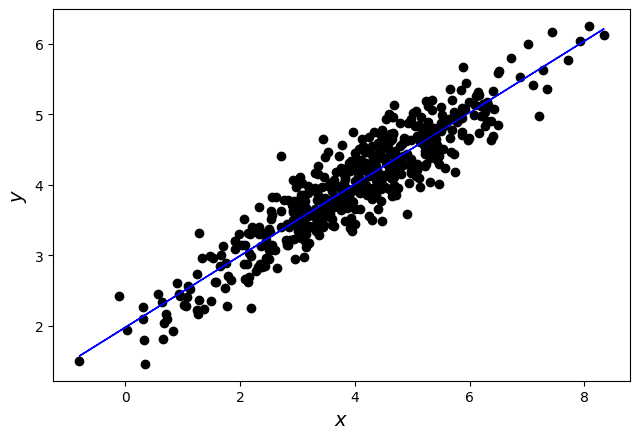

In [10]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(x, y, 'ko', markerfacecolor='k')
ax.plot(x, res['y_hat'], 'b-', linewidth=1.1)
ax.set_xlabel('$x$', fontsize=14)
ax.set_ylabel('$y$', fontsize=14)
plt.tight_layout()
plt.show()


**Activity 4: Symbolic algebra**

Finding the inverse of a matrix symbolically, using `sympy`.

My take (purely personal): **avoid using symbolic stuff, not helpful at all.**

In [11]:
a11, a12, a13, b21, b22, b23, c31, c32, c33 = sp.symbols('a11 a12 a13 b21 b22 b23 c31 c32 c33')
A_m = sp.Matrix([[a11, a12, a13], [b21, b22, b23], [c31, c32, c33]])
A_inv = A_m.inv()
sp.pprint(A_inv)

a = sp.symbols('a')
A_m2 = sp.Matrix([[1, 0, 0], [0, 1, 0], [0, 0, a]])
A_inv2 = A_m2.inv()
sp.pprint(A_inv2)


⎡                                b₂₂⋅c₃₃ - b₂₃⋅c₃₂                             ↪
⎢───────────────────────────────────────────────────────────────────────────── ↪
⎢a₁₁⋅b₂₂⋅c₃₃ - a₁₁⋅b₂₃⋅c₃₂ - a₁₂⋅b₂₁⋅c₃₃ + a₁₂⋅b₂₃⋅c₃₁ + a₁₃⋅b₂₁⋅c₃₂ - a₁₃⋅b₂₂ ↪
⎢                                                                              ↪
⎢                               -b₂₁⋅c₃₃ + b₂₃⋅c₃₁                             ↪
⎢───────────────────────────────────────────────────────────────────────────── ↪
⎢a₁₁⋅b₂₂⋅c₃₃ - a₁₁⋅b₂₃⋅c₃₂ - a₁₂⋅b₂₁⋅c₃₃ + a₁₂⋅b₂₃⋅c₃₁ + a₁₃⋅b₂₁⋅c₃₂ - a₁₃⋅b₂₂ ↪
⎢                                                                              ↪
⎢                                b₂₁⋅c₃₂ - b₂₂⋅c₃₁                             ↪
⎢───────────────────────────────────────────────────────────────────────────── ↪
⎣a₁₁⋅b₂₂⋅c₃₃ - a₁₁⋅b₂₃⋅c₃₂ - a₁₂⋅b₂₁⋅c₃₃ + a₁₂⋅b₂₃⋅c₃₁ + a₁₃⋅b₂₁⋅c₃₂ - a₁₃⋅b₂₂ ↪

↪                                      -a₁₂⋅c₃₃ + a₁₃⋅c₃₂                      ↪
↪ ────  ───────────────────

This markdown was constructed based on the IPYNB code below.

In [12]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import sympy as sp
# import statsmodels.api as sm
#
# b = 0.5    # Propensity to consume
# a = 1.0    # Basic consumption
# I = 0.0    # Investment
# G = 0.2    # Government spending
#
# A_mat = np.array([[1, -1], [-b, 1]])
# d_vec = np.array([I + G, a])
#
# # Boring solution:
# Y_an = 1 / (1 - b) * (I + G + a)
# C_an = 1 / (1 - b) * (b * (I + G) + a)
#
# print('Boring Solution')
# print(pd.DataFrame([[Y_an, C_an]], columns=['Y', 'C']).to_string(index=False))
#
# # Using linear algebra:
# x_solve = np.linalg.solve(A_mat, d_vec)   # preferred: avoids explicitly forming the inverse
#
# print('\nSolution with linear algebra')
# print(pd.DataFrame([x_solve], columns=['Y', 'C']).to_string(index=False))
#
#
# # ----- next cell -----
#
# # A Singular Matrix:
# X_mat = np.array([[3, 4, 5], [0, 1, 2], [6, 8, 10]], dtype=float)
#
# print(X_mat[2, :] - 2 * X_mat[0, :])
#
#
# # ----- next cell -----
#
# def magic_odd(n):
#     '''
#     This function constructs an odd-order magic square
#     Input:
#     n: order of the square (odd)
#     Output:
#     M: n by n magic square
#     '''
#     M = np.zeros((n, n), dtype=int)
#     i, j = 0, n // 2
#     for num in range(1, n * n + 1):
#         M[i, j] = num
#         ni, nj = (i - 1) % n, (j + 1) % n
#         if M[ni, nj]:
#             ni, nj = (i + 1) % n, j
#         i, j = ni, nj
#     return M
#
# Y_mat = magic_odd(3).astype(float)
# Y_mat
#
#
# # ----- next cell -----
#
# def my_det(X):
#     '''
#     This function computes the Determinant of a square matrix
#     Input:
#     X: Square matrix
#     Output:
#     D: determinant of the matrix X
#     '''
#     X = np.asarray(X, dtype=float)
#     n, m = X.shape
#     if n != m:
#         raise ValueError('Input matrix not a square matrix.')
#     eig_val = np.linalg.eigvals(X)
#     D = np.prod(eig_val).real
#     if abs(D) < 1e-13:
#         D = 0.0
#     return float(D)
#
# print('Using the built-in function')
# print([float(np.linalg.det(X_mat)), float(np.linalg.det(Y_mat))])
#
# print('Using our own function')
# print([my_det(X_mat), my_det(Y_mat)])
#
#
# # ----- next cell -----
#
# def rref(X, tol=1e-12):
#     '''
#     This function computes the reduced row-echelon form of a matrix
#     Input:
#     X: Matrix
#     Output:
#     A: reduced row-echelon form of X
#     '''
#     A = np.array(X, dtype=float)
#     n_rows, n_cols = A.shape
#     pivot_row = 0
#     for col in range(n_cols):
#         if pivot_row >= n_rows:
#             break
#         piv = np.argmax(np.abs(A[pivot_row:, col])) + pivot_row
#         if abs(A[piv, col]) < tol:
#             continue
#         A[[pivot_row, piv]] = A[[piv, pivot_row]]
#         A[pivot_row] = A[pivot_row] / A[pivot_row, col]
#         for r in range(n_rows):
#             if r != pivot_row:
#                 A[r] = A[r] - A[r, col] * A[pivot_row]
#         pivot_row += 1
#     return A
#
# def my_rank(X):
#     '''
#     This function computes the rank of a square matrix
#     Input:
#     X: Square matrix
#     Output:
#     rank: rank of the matrix X
#     '''
#     X = np.asarray(X, dtype=float)
#     n, m = X.shape
#     if n != m:
#         raise ValueError('Input matrix not a square matrix.')
#     ech_mat = rref(X)
#     sum_ech_mat = np.sum(np.abs(ech_mat), axis=1)
#     return int(n - np.sum(sum_ech_mat == 0))
#
# print('Using the built-in function')
# print([int(np.linalg.matrix_rank(X_mat)), int(np.linalg.matrix_rank(Y_mat))])
#
# print('Using our own function')
# print([my_rank(X_mat), my_rank(Y_mat)])
#
#
# # ----- next cell -----
#
# print(np.linalg.inv(Y_mat))
#
#
# # ----- next cell -----
#
# def my_adjoint(X):
#     '''
#     This function computes the adjoint matrix of a square matrix
#     Input:
#     X: Square matrix
#     Output:
#     D: adjoint of the matrix X
#     '''
#     X = np.asarray(X, dtype=float)
#     n, m = X.shape
#     if n != m:
#         raise ValueError('Input matrix not a square matrix.')
#     C = np.empty((n, n))
#     idx = np.arange(n)
#     for ki in range(n):
#         for kj in range(n):
#             minor = X[np.ix_(idx[idx != ki], idx[idx != kj])]
#             C[ki, kj] = (-1) ** (ki + kj) * my_det(minor)
#     return C.T
#
# def my_inv(X):
#     '''
#     This function computes the Inverse of a square matrix if it exists
#     Input:
#     X: Square matrix
#     Output:
#     inv_mat: Inverse of the matrix X
#     '''
#     X = np.asarray(X, dtype=float)
#     n, m = X.shape
#     if n != m:
#         raise ValueError('Input matrix not a square matrix.')
#     if my_rank(X) != n:
#         raise ValueError('Input matrix not full rank.')
#     return (1 / my_det(X)) * my_adjoint(X)
#
# print(my_inv(Y_mat))
#
#
# # ----- next cell -----
#
# rng = np.random.default_rng(4567)
#
# n = 500
# mean_x, variance_x = 4.0, 2.0
# variance_e = 0.1
# x = mean_x + np.sqrt(variance_x) * rng.standard_normal(n)
# e = 0 + np.sqrt(variance_e) * rng.standard_normal(n)
#
# beta0, beta1 = 2.0, 0.5
# y = beta0 + beta1 * x + e
#
# # Show that M = X(X'X)^{-1}X' is idempotent
# x_col = x.reshape(-1, 1)
# M = x_col @ np.linalg.inv(x_col.T @ x_col) @ x_col.T
# M_new = M @ M
# diff_sq = (M - M_new) ** 2
# print('Total Squared Difference:')
# print(diff_sq.sum())
#
#
# # ----- next cell -----
#
# def ols_esti(y, X):
#     '''
#     This function computes the Least Squares Estimate
#     Input:
#     y: Dependent Variable    (N,1)
#     X: Independent Variables (N,K)
#     Output:
#     Many stuff you saw in class.
#     '''
#     y = np.asarray(y, dtype=float)
#     X = np.asarray(X, dtype=float)
#     Nx, K = X.shape
#     Ny = y.shape[0]
#     if Ny != Nx:
#         raise ValueError('X and y do not have the same length')
#     N = Nx
#
#     # Coefficients:
#     beta_hat = np.linalg.inv(X.T @ X) @ (X.T @ y)
#     # Predicted values:
#     y_hat = X @ beta_hat
#     # Residuals:
#     e_hat = y - y_hat
#     # Total Variation of the dependent variable
#     SST = (y - y.mean()) @ (y - y.mean())
#     # (SSE) Sum Squared Residuals
#     SSE = e_hat @ e_hat
#     # SSR/SST or "r-squared" is the ratio of the variation in y explained by the model and the total variation of y
#     R2 = 1 - (SSE / SST)
#     # Adjusted "r-squared".
#     R2A = 1 - (SSE / (N - K)) / (SST / (N - 1))
#     sigma2_hat = SSE / (N - K)
#
#     var_covar = sigma2_hat * np.linalg.inv(X.T @ X)
#     SEbeta_hat = np.sqrt(np.diag(var_covar))
#
#     return {
#         'beta_hat': beta_hat, 'y_hat': y_hat, 'e_hat': e_hat,
#         'SST': SST, 'SSE': SSE, 'R2': R2, 'R2A': R2A, 'sigma2_hat': sigma2_hat,
#         'var_covar': var_covar, 'SEbeta_hat': SEbeta_hat,
#     }
#
# X = np.column_stack([np.ones(n), x])
# res = ols_esti(y, X)
#
# v_names = ['beta_0', 'beta_1']
# print('OLS estimates: our own function')
# print(pd.DataFrame([res['beta_hat']], columns=v_names).to_string(index=False))
#
# # Cross-check against the standard library implementation
# ols_sm = sm.OLS(y, X).fit()
# print('\nOLS estimates: standard library implementation')
# print(pd.DataFrame([ols_sm.params], columns=v_names).to_string(index=False))
#
#
# # ----- next cell -----
#
# fig, ax = plt.subplots(figsize=(6.5, 4.5))
# ax.plot(x, y, 'ko', markerfacecolor='k')
# ax.plot(x, res['y_hat'], 'b-', linewidth=1.1)
# ax.set_xlabel('$x$', fontsize=14)
# ax.set_ylabel('$y$', fontsize=14)
# plt.tight_layout()
# plt.show()
#
#
# # ----- next cell -----
#
# a11, a12, a13, b21, b22, b23, c31, c32, c33 = sp.symbols('a11 a12 a13 b21 b22 b23 c31 c32 c33')
# A_m = sp.Matrix([[a11, a12, a13], [b21, b22, b23], [c31, c32, c33]])
# A_inv = A_m.inv()
# sp.pprint(A_inv)
#
# a = sp.symbols('a')
# A_m2 = sp.Matrix([[1, 0, 0], [0, 1, 0], [0, 0, a]])
# A_inv2 = A_m2.inv()
# sp.pprint(A_inv2)